<a href="https://colab.research.google.com/github/flipreis21/PPEC0039/blob/main/Estima%C3%A7%C3%A3o_de_par%C3%A2metros_e_Correla%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inferência Estatística e Estimação de Parâmetros

Bem-vindo a este notebook de estudos! Este material foi desenhado para ser uma aula prática e teórica sobre **Estimação de Parâmetros e Correlação**, com forte embasamento nos Capítulos 10 e 11 do livro *[Estatística Básica](https://www.professores.uff.br/jutriavaldes/wp-content/uploads/sites/196/2019/08/Book_EstatBas-Morettin-Bussab.pdf)* (Bussab & Morettin).

## 1. Introdução e Contextualização

Até o momento em seus estudos de Estatística, você provavelmente lidou com duas áreas distintas:
1. **Estatística Descritiva:** Como organizar, resumir e visualizar um conjunto de dados que já temos em mãos.
2. **Probabilidade:** A base matemática que nos permite calcular a chance de eventos ocorrerem em cenários teóricos conhecidos.

A **Inferência Estatística** (foco deste notebook) é a ponte que une esses dois mundos. No mundo real e no planejamento de experimentos, quase nunca temos acesso a todos os dados que gostaríamos de analisar. Seja por questões de custo, tempo ou impossibilidade física, não podemos testar todas as peças de uma fábrica, entrevistar todos os eleitores de um país ou aplicar um medicamento em todos os pacientes do mundo.

O que fazemos? Nós coletamos uma **amostra** (uma parte representativa) e usamos as leis da probabilidade para fazer afirmações seguras sobre a **população** inteira.

### Conceitos Fundamentais (Capítulo 10 - Bussab & Morettin)

Para que a nossa transição da amostra para a população seja cientificamente válida, precisamos estabelecer um vocabulário estatístico conhecido:

* **População:** É o conjunto de todos os elementos que estamos interessados em estudar.
* **Amostra Aleatória Simples:** É um subconjunto da população onde cada elemento foi retirado de forma independente e tinha exatamente a mesma chance de ser escolhido.
* **Parâmetro:** É uma medida numérica descritiva da *população*. É um valor fixo, constante, porém geralmente desconhecido.
    * *Exemplos:* A média populacional $\mu$, a variância populacional $\sigma^2$ e a proporção populacional $p$.
* **Estatística (ou Estimador):** É uma medida numérica calculada a partir dos dados da *amostra*. Como depende de quais elementos foram sorteados, uma estatística é uma **variável aleatória** ela muda a cada nova coleta.
    * *Exemplos:* A média amostral $\bar{X}$, a variância amostral $S^2$ e a proporção amostral $\hat{p}$.

**O Paradigma da estatística:**
O nosso objetivo principal a partir de agora é usar uma Estatística (algo que podemos calcular) para "chutar" ou inferir cientificamente o valor de um Parâmetro (algo que queremos descobrir), controlando e quantificando matematicamente a nossa margem de erro.

![O Paradigma da Estatística](https://raw.githubusercontent.com/flipreis21/PPEC0039/main/estimacao_parametros/data/Gemini_Generated_Image_sy7ehnsy7ehnsy7e.png)


## 2. Na Prática: Parâmetro vs. Estatística

Para consolidar a diferença entre parâmetros e esatísticas, vamos realizar uma simulação computacional. Imagine que somos pesquisadores de saúde estudando a altura de todos os **10.000 habitantes** de uma pequena cidade fictícia.

Neste experimento controlado, nós sabemos a altura de todo mundo. Portanto, podemos calcular o **Parâmetro** real (a média populacional, $\mu$).

No entanto, no mundo real, um pesquisador não teria tempo para medir 10.000 pessoas. Ele selecionaria aleatoriamente uma **Amostra** de, digamos, 50 pessoas e calcularia a **Estatística** (a média amostral, $\bar{X}$).

Vamos usar o Python para ver o quão perto a nossa Estatística chega do verdadeiro Parâmetro!

--- RESULTADOS DO EXPERIMENTO ---
Parâmetro (Média da População - 10.000 pessoas): 169.98 cm
Estatística (Média da Amostra - 50 pessoas): 169.95 cm
Erro de Estimação (A diferença entre eles): 0.03 cm



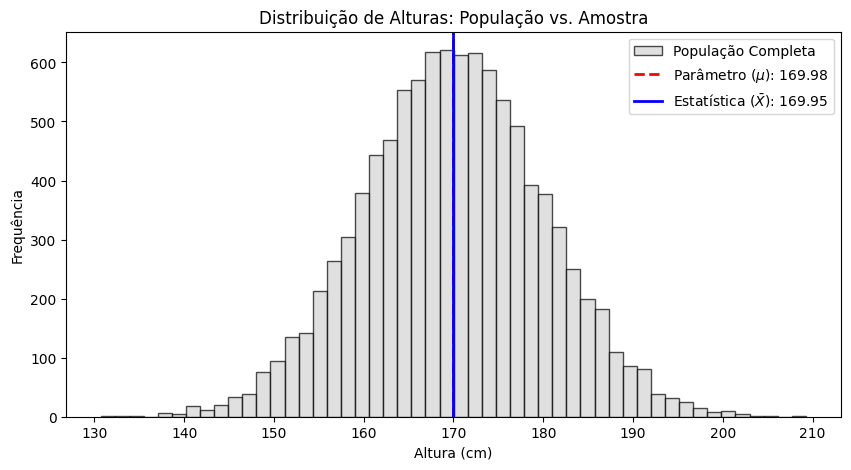

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. CRIANDO A NOSSA POPULAÇÃO (O mundo real e desconhecido)
np.random.seed(42) #Essa linha fixa a aleatoriadade da população ao trava com parâmetro 42, para tornar a população aleatória a cada execução, remover...
populacao = np.random.normal(loc=170, scale=10, size=10000) #parâmetros fictícios adotados aplicados a uma distribuição normal, podem ser alterados para visualização

# Calculando o PARÂMETRO (A média real de toda a população)
parametro_mu = populacao.mean()

# 2. COLETANDO UMA AMOSTRA (O trabalho do pesquisador)
np.random.seed(None) # amostra aleatória, pois parâmetro "none" não trava
tamanho_amostra = 50 # Mude este número para ver o erro de estimação aumentar ou diminuir
amostra = np.random.choice(populacao, size=tamanho_amostra, replace=False)

# Calculando a ESTATÍSTICA (A média estimada a partir da amostra)
estatistica_x_barra = amostra.mean()

# 3. VISUALIZANDO OS RESULTADOS
print(f"--- RESULTADOS DO EXPERIMENTO ---")
print(f"Parâmetro (Média da População - 10.000 pessoas): {parametro_mu:.2f} cm")
print(f"Estatística (Média da Amostra - {tamanho_amostra} pessoas): {estatistica_x_barra:.2f} cm")
print(f"Erro de Estimação (A diferença entre eles): {abs(parametro_mu - estatistica_x_barra):.2f} cm\n")

# Gerando um gráfico para ilustrar
plt.figure(figsize=(10, 5))
plt.hist(populacao, bins=50, color='lightgray', edgecolor='black', alpha=0.7, label='População Completa')
plt.axvline(parametro_mu, color='red', linestyle='dashed', linewidth=2, label=rf'Parâmetro ($\mu$): {parametro_mu:.2f}')
plt.axvline(estatistica_x_barra, color='blue', linestyle='solid', linewidth=2, label=rf'Estatística ($\bar{{X}}$): {estatistica_x_barra:.2f}')

plt.title('Distribuição de Alturas: População vs. Amostra')
plt.xlabel('Altura (cm)')
plt.ylabel('Frequência')
plt.legend()
plt.show()

## 3. A Mágica da Inferência: O Teorema Central do Limite (TCL)

No passo anterior, vimos que a média de uma amostra ($\bar{X}$) quase nunca acerta o parâmetro exato ($\mu$) na mosca. Ela sempre tem um pequeno erro. Mas o que aconteceria se nós repetíssemos esse experimento várias vezes? E se coletássemos centenas de amostras diferentes?

É aqui que entra o **Teorema Central do Limite (TCL)**, o princípio mais importante da inferência.

O TCL prova matematicamente que, se coletarmos várias amostras de tamanho suficientemente grande (geralmente $n \ge 30$), e calcularmos a média de cada uma delas, **a distribuição dessas médias amostrais formará uma curva Normal perfeita**. E o mais incrível: o centro exato dessa nova curva será o verdadeiro parâmetro da população!

> 📖 **Para aprofundamento:** Se você deseja entender a demonstração matemática formal e a aplicação deste teorema na teoria dos erros e medidas experimentais, recomendamos a leitura do excelente material [Teorema Central do Limite](https://if.ufrgs.br/~lang/Textos/Teorema_Central_Limite.pdf), de autoria do Prof. Fernando Lang da Silveira (IF - UFRGS).

Vamos usar o Python para simular um pesquisador que vai sair às ruas e coletar 1.000 amostras diferentes de 50 pessoas cada. Depois, faremos um gráfico com as 1.000 médias que ele calculou.

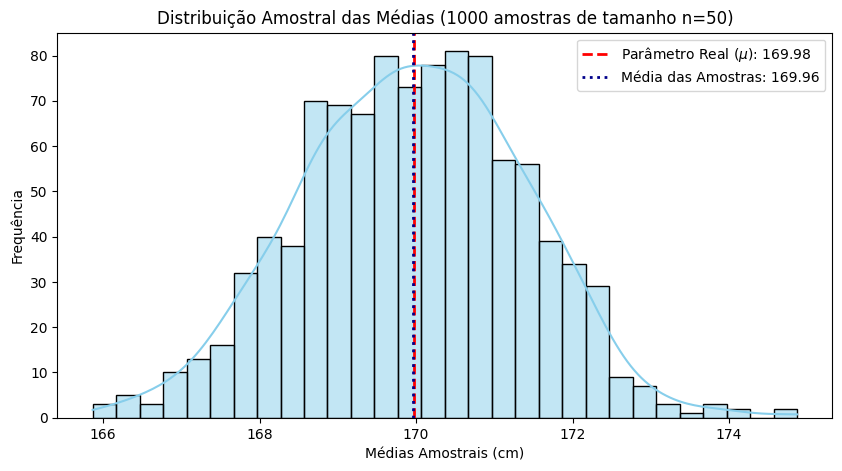

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Biblioteca excelente para gráficos estatísticos

# 1. RECRIANDO A POPULAÇÃO (Para garantir que rodará mesmo se pularmos células)
np.random.seed(42)
populacao = np.random.normal(loc=170, scale=10, size=10000)
parametro_mu = populacao.mean()

# 2. O LOOP DO PESQUISADOR (Coletando 1000 amostras)
n_amostras = 1000
tamanho_amostra = 50
medias_amostrais = [] # Lista vazia para guardar as 1000 médias

# O Python vai repetir esse processo 1000 vezes:
for i in range(n_amostras):
    amostra = np.random.choice(populacao, size=tamanho_amostra, replace=False)
    medias_amostrais.append(amostra.mean()) # Guarda a média na lista

# 3. VISUALIZANDO O TEOREMA CENTRAL DO LIMITE
plt.figure(figsize=(10, 5))

# Plotando a distribuição das MÉDIAS (KDE cria a linha suave da curva Normal)
sns.histplot(medias_amostrais, kde=True, color='skyblue', bins=30, edgecolor='black')

# Desenhando a linha do Parâmetro Real
plt.axvline(parametro_mu, color='red', linestyle='dashed', linewidth=2, label=rf'Parâmetro Real ($\mu$): {parametro_mu:.2f}')

# Calculando a média das médias (deve ser quase idêntica ao parâmetro)
media_das_medias = np.mean(medias_amostrais)
plt.axvline(media_das_medias, color='darkblue', linestyle='dotted', linewidth=2, label=rf'Média das Amostras: {media_das_medias:.2f}')

plt.title(f'Distribuição Amostral das Médias ({n_amostras} amostras de tamanho n={tamanho_amostra})')
plt.xlabel('Médias Amostrais (cm)')
plt.ylabel('Frequência')
plt.legend()
plt.show()

## 4. Teoria da Estimação: O que define um bom Estimador?

No Capítulo 11.2 (p. 298), Bussab e Morettin introduzem formalmente os conceitos matemáticos que os estatísticos usam para julgar se uma fórmula é adequada para estimar um parâmetro populacional.

Imagine que queremos estimar um parâmetro genérico da população, que chamaremos de $\theta$ (pode ser a média $\mu$ ou a variância $\sigma^2$). Para isso, criamos uma fórmula baseada na amostra, que chamamos de **Estimador** ($\hat{\theta}$). Como a amostra é aleatória, $\hat{\theta}$ também é uma variável aleatória e possui sua própria distribuição.

Para que um estimador seja considerado ideal, ele deve cumprir propriedades fundamentais:

### 1. Ausência de Vício ou Viés (Unbiasedness)
Um estimador é dito **não-viesado** (ou imparcial) se o seu valor esperado (a média de todas as estimativas possíveis) for exatamente igual ao verdadeiro parâmetro populacional.
$$\text{Se } E(\hat{\theta}) = \theta \implies \hat{\theta} \text{ é não-viesado}$$

Se $E(\hat{\theta}) \neq \theta$, dizemos que o estimador possui um **vício** ou **viés**, quantificado por:
$$\text{Vício}(\hat{\theta}) = E(\hat{\theta}) - \theta$$

### 2. Eficiência (Variância Mínima)
Se tivermos dois estimadores diferentes ($\hat{\theta}_1$ e $\hat{\theta}_2$) que não possuem viés, o melhor deles será aquele que tiver a **menor variância**. Isso significa que as estimativas ficam mais agrupadas e próximas do alvo, variando menos de uma amostra para outra.
$$\text{Se } Var(\hat{\theta}_1) < Var(\hat{\theta}_2) \implies \hat{\theta}_1 \text{ é mais eficiente que } \hat{\theta}_2$$



### 3. Consistência
Um estimador é consistente se, à medida que o tamanho da amostra ($n$) cresce em direção ao infinito, o valor estimado converge  para o parâmetro real, e sua variância vai a zero.

---

### O Clássico Exemplo Teórico: A Variância Amostral ($n$ vs $n-1$)

Um dos resultados mais intrigantes da teoria da estimação envolve a Variância. Se tentarmos estimar a variância populacional ($\sigma^2$) usando a intuição matemática direta (dividindo pelo tamanho da amostra $n$), descobrimos teoricamente que esse estimador é **viesado**:
$$\hat{\sigma}^2_{\text{viesado}} = \frac{1}{n}\sum_{i=1}^{n}(X_i - \bar{X})^2 \implies E(\hat{\sigma}^2_{\text{viesado}}) = \frac{n-1}{n}\sigma^2$$

Observe que ele sistematicamente **subestima** a verdadeira variância da população. Para corrigir esse viés matemático, os estatísticos deduziram que o estimador não-viesado perfeito (denotado por $S^2$) deve usar $n-1$ no denominador:
$$S^2 = \frac{1}{n-1}\sum_{i=1}^{n}(X_i - \bar{X})^2 \implies E(S^2) = \sigma^2$$

É por isso que nas funções estatísticas e códigos de programação sempre especificamos correções de graus de liberdade (como o argumento `ddof=1` no Python)!

In [28]:
import numpy as np
import scipy.stats as stats

# 1. RECUPERANDO A NOSSA PRIMEIRA AMOSTRA (O cenário do mundo real)
# Vamos supor que você foi a campo e coletou a altura de 50 pessoas
np.random.seed(15) # Semente diferente apenas para simularmos uma coleta específica
amostra_real = np.random.normal(loc=170, scale=10, size=50)

# 2. CALCULANDO AS ESTATÍSTICAS DA AMOSTRA
n = len(amostra_real)
media_amostral = np.mean(amostra_real)
desvio_padrao_amostral = np.std(amostra_real, ddof=1) # ddof=1 pois é amostra (n-1)

# 3. CONSTRUINDO O INTERVALO DE CONFIANÇA (Capítulo 11.6)
nivel_confianca = 0.95
graus_liberdade = n - 1

# Calculando o Erro Padrão da Média (Capítulo 11.7)
erro_padrao = desvio_padrao_amostral / np.sqrt(n)

# Função pronta do Scipy para calcular o intervalo usando t de Student
limite_inferior, limite_superior = stats.t.interval(
    confidence=nivel_confianca,
    df=graus_liberdade,
    loc=media_amostral,
    scale=erro_padrao
)

# Margem de erro é a distância da média até um dos limites
margem_erro = limite_superior - media_amostral

# 4. EXIBINDO OS RESULTADOS
print("-" * 50)
print("ESTIMAÇÃO DE PARÂMETROS - RESULTADOS")
print("-" * 50)
print(f"Estimação Pontual (Média da Amostra): {media_amostral:.2f} cm")
print(f"Margem de Erro Calculada: ± {margem_erro:.2f} cm")
print(f"Intervalo de Confiança (95%): [{limite_inferior:.2f} cm , {limite_superior:.2f} cm]")
print("-" * 50)
print(f"Interpretação: Com base apenas nesta amostra, temos 95% de confiança")
print(f"de que a verdadeira média de toda a população está dentro deste intervalo.")

--------------------------------------------------
ESTIMAÇÃO DE PARÂMETROS - RESULTADOS
--------------------------------------------------
Estimação Pontual (Média da Amostra): 168.70 cm
Margem de Erro Calculada: ± 2.82 cm
Intervalo de Confiança (95%): [165.88 cm , 171.52 cm]
--------------------------------------------------
Interpretação: Com base apenas nesta amostra, temos 95% de confiança
de que a verdadeira média de toda a população está dentro deste intervalo.


## 5. Determinação do Tamanho Mínimo da Amostra

No passo anterior, coletamos uma amostra de $n = 50$ e descobrimos a nossa margem de erro. Mas e se estivéssemos na fase de planejamento do experimento? Como um pesquisador determina, cientificamente, quantas pessoas ou objetos ele precisa medir?

Conforme discutido por Bussab e Morettin no **Tópico 10.11 (p. 287)** e no **Capítulo 11**, a Margem de Erro ($E$) de uma estimativa depende de três fatores:
1. **O nível de confiança desejado:** que dita o valor crítico (como o escore $Z$).
2. **A variabilidade dos dados:** representada pelo desvio padrão populacional ($\sigma$) ou por uma estimativa amostral piloto ($S$).
3. **O tamanho da amostra ($n$):** quanto maior a amostra, menor o erro.

Se fixarmos o erro máximo tolerável ($E$) e o nível de confiança, podemos isolar matematicamente o tamanho amostral $n$.

### 1. Tamanho da Amostra para Estimar a Média ($\mu$)
Utilizando a aproximação pela distribuição Normal Padrão para o planejamento inicial:
$$n = \left( \frac{Z_{\alpha/2} \cdot \sigma}{E} \right)^2$$

### 2. Tamanho da Amostra para Estimar uma Proporção ($p$)
Quando o nosso experimento quer estimar uma taxa ou porcentagem (ex: proporção de cura de um tratamento, intenção de votos):
$$n = \frac{Z_{\alpha/2}^2 \cdot p \cdot (1-p)}{E^2}$$

*Nota Teórica:* Se não conhecemos o valor da proporção populacional $p$ de antemão, adotamos o cenário conservador de **variância máxima**, definindo $p = 0,5$. Isso garante o maior tamanho de amostra seguro possível.

Vamos criar uma função em Python para calcular esses tamanhos mínimos automaticamente!

In [29]:
import math
import scipy.stats as stats

def calcular_n_media(erro_maximo, desvio_padrao, confianca=0.95):
    """
    Calcula o tamanho mínimo de amostra para estimar uma média.
    """
    alpha = 1 - confianca
    # Encontra o valor crítico Z correspondente à confiança desejada
    z_critico = abs(stats.norm.ppf(alpha / 2))

    # Aplicação da fórmula matemática
    n = ((z_critico * desvio_padrao) / erro_maximo) ** 2

    # Sempre arredondamos para cima, pois não existe fração de observação/indivíduo
    return math.ceil(n)

def calcular_n_proporcao(erro_maximo, p_esperado=0.5, confianca=0.95):
    """
    Calcula o tamanho mínimo de amostra para estimar uma proporção.
    """
    alpha = 1 - confianca
    z_critico = abs(stats.norm.ppf(alpha / 2))

    # Aplicação da fórmula matemática
    n = (z_critico**2 * p_esperado * (1 - p_esperado)) / (erro_maximo**2)

    return math.ceil(n)

# --- APLICANDO OS EXEMPLOS DE PLANEJAMENTO ---
print("-" * 60)
print("PLANEJAMENTO DE EXPERIMENTOS: CÁLCULO DE TAMANHO DE AMOSTRA")
print("-" * 60)

# Exemplo A: Queremos estimar a média de altura com erro máximo de 2 cm.
# Um estudo piloto anterior indicou que o desvio padrão é de aproximadamente 10 cm.
erro_tolerado_media = 2.0
sigma_estimado = 10.0
n_necessario_media = calcular_n_media(erro_maximo=erro_tolerado_media, desvio_padrao=sigma_estimado, confianca=0.95)

print(f"Para estimar a MÉDIA (Erro máx: ±{erro_tolerado_media}cm | Confiança: 95%):")
print(f"👉 Tamanho mínimo da amostra necessário: {n_necessario_media} observações.\n")

# Exemplo B: Queremos estimar a proporção de eficácia de um novo processo.
# Não temos dados anteriores, então usaremos o cenário de máxima variância (p=0.5).
# Queremos uma margem de erro máxima de 4% (0.04).
erro_tolerado_prop = 0.04
n_necessario_prop = calcular_n_proporcao(erro_maximo=erro_tolerado_prop, confianca=0.95)

print(f"Para estimar uma PROPORÇÃO (Erro máx: ±{erro_tolerado_prop*100}% | Confiança: 95%):")
print(f"👉 Tamanho mínimo da amostra necessário: {n_necessario_prop} observações.")
print("-" * 60)

------------------------------------------------------------
PLANEJAMENTO DE EXPERIMENTOS: CÁLCULO DE TAMANHO DE AMOSTRA
------------------------------------------------------------
Para estimar a MÉDIA (Erro máx: ±2.0cm | Confiança: 95%):
👉 Tamanho mínimo da amostra necessário: 97 observações.

Para estimar uma PROPORÇÃO (Erro máx: ±4.0% | Confiança: 95%):
👉 Tamanho mínimo da amostra necessário: 601 observações.
------------------------------------------------------------


## 6. Aplicação Prática: Inspeção por Amostragem em Dados Geoespaciais
Para consolidar o que aprendemos sobre o Capítulo 11 de Bussab & Morettin, vamos aplicar as fórmulas de estimação ao contexto de dados geospaciais. Na validação de produtos cartográficos, utilizamos a amostragem para inspecionar lotes de feições geoespaciais e estimar erros posicionais.

### Caso 1: Estimação do Erro Posicional Planimétrico (Intervalo de Confiança)
Durante a inspeção de qualidade de uma carta topográfica na escala 1:1.000, um engenheiro cartógrafo coletou uma amostra aleatória de **35 pontos de controle** (Ground Control Points) para medir o erro de deslocamento linear (em metros). Como a variabilidade total do lote é desconhecida, ele utilizará a média amostral, o desvio padrão corrigido ($n-1$) e a distribuição **t de Student** para estimar, com 95% de confiança, o erro planimétrico médio real do produto para verificar se ele atende aos requisitos do PEC Classe A (cujo erro médio esperado deve estar desalinhado por poucos centímetros/metros).

### Caso 2: Dimensionamento Amostral para Feições Omissas (Proporção)
Um analista geoespacial precisa inspecionar um grande banco de dados geográficos para estimar a proporção de feições que sofreram "omissão" (erros onde uma feição real em campo foi esquecida no mapa). Ele deseja que a margem de erro máxima da sua estimativa seja de **3% (0.03)** com um nível de confiança de 95%. Como é a primeira inspeção desse lote e ele não tem dados históricos da taxa de erro da empresa de mapeamento, ele adotará o critério de **variância máxima** ($p = 0.5$) para calcular o tamanho mínimo da amostra (número de feições a checar).

Vamos programar essas soluções abaixo!

In [30]:
import numpy as np
import scipy.stats as stats
import math

print("=" * 70)
print("   CONTROLE DE QUALIDADE DE DADOS GEOESPACIAIS (ET-CQDG) - PRÁTICA   ")
print("=" * 70)

# -------------------------------------------------------------------------
# CASO 1: INTERVALO DE CONFIANÇA PARA ERRO PLANIMÉTRICO (MÉDIA)
# -------------------------------------------------------------------------
# Simulando o erro de deslocamento medido em 35 pontos de controle (em metros)
np.random.seed(101)
erros_posicionais = np.random.normal(loc=0.28, scale=0.12, size=35) # média de 28cm de erro

# Estatísticas Amostrais
n_pontos = len(erros_posicionais)
media_erro = np.mean(erros_posicionais)
# IMPORTANTE: ddof=1 (n-1) para garantir o estimador não-viesado da variância!
dp_erro = np.std(erros_posicionais, ddof=1)

# Parâmetros do Intervalo de Confiança (95%)
confianca_ic = 0.95
graus_liberdade = n_pontos - 1
erro_padrao_estimador = dp_erro / np.sqrt(n_pontos)

# Construindo o IC com t de Student
ic_inf, ic_sup = stats.t.interval(
    confidence=confianca_ic,
    df=graus_liberdade,
    loc=media_erro,
    scale=erro_padrao_estimador
)

print("🗺️ INSPEÇÃO 1: Avaliação de Acurácia Posicional Planimétrica")
print(f"Quantidade de pontos de controle inspecionados (n): {n_pontos}")
print(f"Erro Médio Amostral (Estimativa Pontual): {media_erro:.3f} metros")
print(f"Desvio Padrão Corrigido do Erro (S): {dp_erro:.3f} metros")
print(f"Intervalo de Confiança (95%): [{ic_inf:.3f} m , {ic_sup:.3f} m]")
print(f"👉 Conclusão Técnica: Estamos 95% confiantes de que o erro planimétrico\n"
      f"   médio real de TODO o produto cartográfico está entre {ic_inf:.2f}m e {ic_sup:.2f}m.")
print("-" * 70)

   CONTROLE DE QUALIDADE DE DADOS GEOESPACIAIS (ET-CQDG) - PRÁTICA   
🗺️ INSPEÇÃO 1: Avaliação de Acurácia Posicional Planimétrica
Quantidade de pontos de controle inspecionados (n): 35
Erro Médio Amostral (Estimativa Pontual): 0.307 metros
Desvio Padrão Corrigido do Erro (S): 0.127 metros
Intervalo de Confiança (95%): [0.263 m , 0.350 m]
👉 Conclusão Técnica: Estamos 95% confiantes de que o erro planimétrico
   médio real de TODO o produto cartográfico está entre 0.26m e 0.35m.
----------------------------------------------------------------------


In [32]:
# -------------------------------------------------------------------------
# CASO 2: DIMENSIONAMENTO DE AMOSTRA PARA OMISSÃO DE FEIÇÕES (PROPORÇÃO)
# -------------------------------------------------------------------------
erro_tolerado_omissao = 0.03  # Margem de erro de 3%
confianca_planejamento = 0.95 # Confiança de 95%
p_conservador = 0.5           # Máxima variância (inspeção inédita)

# Valor crítico Z para 95% de confiança
alpha = 1 - confianca_planejamento
z_critico = abs(stats.norm.ppf(alpha / 2))

# Fórmula de dimensionamento amostral para proporção
n_minimo_feicoes = (z_critico**2 * p_conservador * (1 - p_conservador)) / (erro_tolerado_omissao**2)
n_minimo_feicoes = math.ceil(n_minimo_feicoes) # Arredondando para cima

print("📊 INSPEÇÃO 2: Dimensionamento de Amostra para Erros de Omissão")
print(f"Margem de erro máxima estabelecida (E): ± {erro_tolerado_omissao*100}%")
print(f"Nível de Confiança exigido: {confianca_planejamento*100}% (Z = {z_critico:.3f})")
print(f"👉 Tamanho mínimo da amostra (feições a inspecionar): {n_minimo_feicoes}")
print("=" * 70)

📊 INSPEÇÃO 2: Dimensionamento de Amostra para Erros de Omissão
Margem de erro máxima estabelecida (E): ± 3.0%
Nível de Confiança exigido: 95.0% (Z = 1.960)
👉 Tamanho mínimo da amostra (feições a inspecionar): 1068


## 5. Análise de Correlação e Medidas de Associação

A partir de agora, entramos no estudo de relacionamento entre duas ou mais variáveis para entender o quanto uma interfere ou está associada ao resultado da outra.

### 1. Diagramas de Dispersão
O primeiro passo analítico é sempre geométrico: plotar um diagrama de dispersão cartesiano (gráfico X-Y). Ele nos permite examinar visualmente a ocorrência de tendências (lineares ou não), agrupamentos e a presença de valores discrepantes (*outliers*).

### 2. A Covariância $C(X,Y)$
Mede a co-variação, ou seja, como as duas variáveis variam de forma conjunta. Se dividirmos o gráfico em quatro quadrantes centrados nas médias ($\bar{X}, \bar{Y}$):
* Se a maioria dos pontos cai nos quadrantes **I e III**, os produtos dos desvios são positivos, gerando uma **covariância positiva** (as variáveis crescem juntas).
* Se caem nos quadrantes **II e IV**, os produtos são negativos, indicando uma **covariância negativa** (relação inversa).

A fórmula da covariância amostral para $n$ pares de dados é:
$$C(X,Y) = \frac{\sum (X_i - \bar{X}) \cdot (Y_i - \bar{Y})}{n}$$

*Limitação:* A covariância é afetada pelas unidades de medida e ordens de grandeza (ex: metros, quilos), o que impede comparar o grau de relação entre experimentos diferentes.

### 3. Coeficiente de Correlação de Pearson ($r$)
Para remover a influência das unidades, dividimos a covariância pelo produto dos desvios padrões de X e Y. Isso padroniza o indicador, fazendo com que ele varie estritamente entre **-1 e 1**:
$$r = \frac{C(X,Y)}{S_x \cdot S_y}$$

* **$r = 1$:** Relação linear positiva perfeita.
* **$r = -1$:** Relação linear negativa perfeita.
* **$r = 0$:** Ausência de relação linear.

### 4. Coeficiente de Determinação ($r^2$)
Definido simplesmente elevando o coeficiente de Pearson ao quadrado ($r^2$). Sua interpretação é extremamente prática no planejamento de experimentos: ele indica a **proporção da variação de Y que é explicada ou explicável pela variação da variável X** (e vice-versa).

Vamos replicar o exemplo prático do material (Horas sem Dormir vs. Número de Erros) para calcular e visualizar essas medidas!

        MENSURAÇÃO DE ASSOCIAÇÃO E CORRELAÇÃO LINEAR        
Média de Horas sem Dormir (X): 16.0 horas
Média de Erros cometidos (Y): 10.6 erros
Covariância C(X,Y): 15.20
Coeficiente de Correlação de Pearson (r): 0.801467
Coeficiente de Determinação (r²): 0.642349
------------------------------------------------------------
Interpretação do r²: 64.23% da variação nos erros cometidos
é explicada pelas horas que os indivíduos passaram sem dormir.


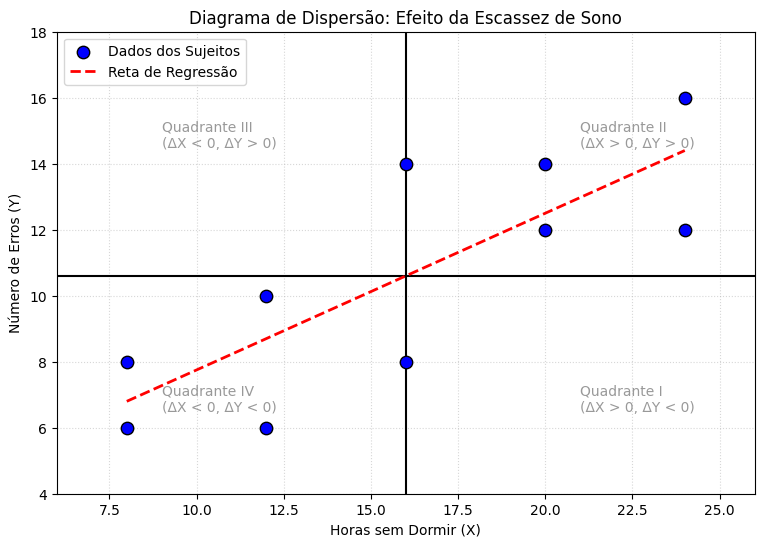

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ENTRADA DOS DADOS (Tabela 2 do material de apoio - Horas sem dormir vs Erros)
# X = Horas sem dormir | Y = Número de erros
X = np.array([8, 8, 12, 12, 16, 16, 20, 20, 24, 24])
Y = np.array([8, 6, 6, 10, 8, 14, 14, 12, 16, 12])

n = len(X)
media_X = np.mean(X)
media_Y = np.mean(Y)

# 2. CÁLCULO MANUAL DA COVARIÂNCIA (Conforme Equação 1 do PDF)
desvios_X = X - media_X
desvios_Y = Y - media_Y
produto_desvios = desvios_X * desvios_Y

# Divisão por n conforme a fórmula (1) apresentada no material
covariancia = np.sum(produto_desvios) / n

# 3. CÁLCULO DOS DESVIOS PADRÕES E PEARSON
# Nota: O material calcula os desvios padrões populacionais no denominador (divido por n)
S_X = np.sqrt(np.sum(desvios_X**2) / n)
S_Y = np.sqrt(np.sum(desvios_Y**2) / n)

r_pearson = covariancia / (S_X * S_Y)
r_quadrado = r_pearson ** 2

# 4. EXIBIÇÃO DOS RESULTADOS ANALÍTICOS
print("=" * 60)
print("        MENSURAÇÃO DE ASSOCIAÇÃO E CORRELAÇÃO LINEAR        ")
print("=" * 60)
print(f"Média de Horas sem Dormir (X): {media_X:.1f} horas")
print(f"Média de Erros cometidos (Y): {media_Y:.1f} erros")
print(f"Covariância C(X,Y): {covariancia:.2f}")
print(f"Coeficiente de Correlação de Pearson (r): {r_pearson:.6f}")
print(f"Coeficiente de Determinação (r²): {r_quadrado:.6f}")
print("-" * 60)
print(f"Interpretação do r²: {r_quadrado*100:.2f}% da variação nos erros cometidos")
print(f"é explicada pelas horas que os indivíduos passaram sem dormir.")
print("=" * 60)

# 5. CONSTRUÇÃO DO DIAGRAMA DE DISPERSÃO COM QUADRANTES
plt.figure(figsize=(9, 6))
plt.scatter(X, Y, color='blue', s=80, edgecolors='black', zorder=3, label='Dados dos Sujeitos')

# Desenhar as linhas das médias para evidenciar os Quadrantes I, II, III e IV
plt.axvline(media_X, color='black', linestyle='-', linewidth=1.5)
plt.axhline(media_Y, color='black', linestyle='-', linewidth=1.5)

# Linha de tendência linear (Mínimos Quadrados)
m, b = np.polyfit(X, Y, 1)
plt.plot(X, m*X + b, color='red', linestyle='--', linewidth=2, label='Reta de Regressão')

# Anotações dos Quadrantes conforme a teoria do material
plt.text(21, 14.5, 'Quadrante II\n(ΔX > 0, ΔY > 0)', fontsize=10, color='gray', alpha=0.8)
plt.text(9, 14.5, 'Quadrante III\n(ΔX < 0, ΔY > 0)', fontsize=10, color='gray', alpha=0.8)
plt.text(9, 6.5, 'Quadrante IV\n(ΔX < 0, ΔY < 0)', fontsize=10, color='gray', alpha=0.8)
plt.text(21, 6.5, 'Quadrante I\n(ΔX > 0, ΔY < 0)', fontsize=10, color='gray', alpha=0.8)

plt.title('Diagrama de Dispersão: Efeito da Escassez de Sono')
plt.xlabel('Horas sem Dormir (X)')
plt.ylabel('Número de Erros (Y)')
plt.xlim(6, 26)
plt.ylim(4, 18)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

## 6. Conclusão da Aula

Ao longo deste Jupyter Notebook, nós integramos os fundamentos teóricos da modelagem estatística com a execução computacional em Python, cobrindo duas grandes áreas da inferência:

1. **A Teoria da Estimação e Amostragem:** Onde entendemos o comportamento das variáveis aleatórias por meio das distribuições amostrais, calculamos intervalos de confiança robustos utilizando a correção para estimadores não-viesados ($n-1$) e aprendemos a dimensionar o tamanho mínimo de uma amostra para o planejamento eficiente de experimentos.
2. **A Análise de Associação:** Onde deixamos de olhar para variáveis isoladas para estudar a variação conjunta (covariância), o grau de relacionamento linear entre dois fenômenos (Pearson) e a proporção de impacto que uma variável exerce sobre a outra ($r^2$), sem a necessidade de adentrar em testes de hipóteses formais.

Este ecossistema foi elaborado com conhecimentos adquiridos nas aulas do componente PPEC0039 - Esatística e experimentos e leitura das referências bibliográficas abaixo, formatado com auxílio de IA - Generativa, mais especificamente o GEMINI Pro 3.1, utilizado para formatação do markdown, correção de semântica e escrita e ajuda no uso de bibliotecas e funções python para resolução dos exemplos.

---

## 📚 Fontes e Referências Bibliográficas

Este material de ensino foi construído, adaptado e fundamentado com base nas seguintes fontes de referência:

* **Livro Base (Capítulos 10 e 11):** BUSSAB, Wilton de O.; MORETTIN, Pedro A. *Estatística Básica*. 9. ed. São Paulo: Saraiva Uni, 2017. (Foco em Introdução à Inferência Estatística e Teoria da Estimação).Disponível em: <https://www.professores.uff.br/jutriavaldes/wp-content/uploads/sites/196/2019/08/Book_EstatBas-Morettin-Bussab.pdf>
* **Material de Apoio e Teoria dos Erros:**
    SILVEIRA, Fernando Lang da. *Teorema Central do Limite*. Instituto de Física, Universidade Federal do Rio Grande do Sul (UFRGS). Disponível em: <https://if.ufrgs.br/~lang/Textos/Teorema_Central_Limite.pdf>.
* **Material Didático de Associação apresentado pelo prof. Mauro:**
    GUIMARÃES, Paulo Ricardo B. *Análise de Correlação e Medidas de Associação*. Texto de apoio acadêmico (Foco em diagramas de dispersão, cálculo analítico de covariância e interpretação geométrica dos quadrantes de desvios).